# Application laboratory: robot planning as inference on a trajectory graph

A finite-horizon robot path $x_{0:T}$ can be represented by a chain-structured graphical model. Transition factors enforce local motion, obstacle factors forbid invalid states, and state costs favor desirable regions. A Gibbs path law

$$
P(x_{0:T})\propto \mathbf 1[x_0=s]\mathbf 1[x_T=g]\prod_{t=0}^{T-1}K(x_{t+1}\mid x_t)\prod_{t=1}^{T-1}e^{-\beta c(x_t)}
$$

turns planning into both MAP optimization and soft path inference. This is the finite-state precursor of linearly solvable control and path-space generative models developed later.

In [1]:
CHAPTER_DIR="ch11"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / CHAPTER_DIR).exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

def save_figure(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    print("Saved", stem)

def draw_dark_nodes(G, pos, labels=None, ax=None, node_size=1200, arrows=False, **kwargs):
    if ax is None: ax=plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#303030", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)
    return ax

def annotate_heatmap(ax, image, values, fmt=".2f"):
    arr=np.asarray(values)
    lo,hi=np.nanmin(arr),np.nanmax(arr)
    mid=(lo+hi)/2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color="white" if arr[i,j] < mid else "black"
            ax.text(j,i,format(arr[i,j],fmt),ha="center",va="center",color=color,fontsize=11)

In [2]:
from itertools import product
W=4; H=4; T=7; start=(0,0); goal=(3,3); obstacles={(1,1),(2,1)}
states=[(i,j) for i in range(W) for j in range(H) if (i,j) not in obstacles]
idx={s:k for k,s in enumerate(states)}
def nbrs(s):
    i,j=s
    cand=[s,(i+1,j),(i-1,j),(i,j+1),(i,j-1)]
    return [q for q in cand if q in idx]
# dynamic programming over paths
paths=[([start],1.0)]
beta=.8
for t in range(T):
    new=[]
    for path,w in paths:
        for q in nbrs(path[-1]):
            # mild cost for staying and for distance from goal
            c=.25*(q==path[-1])+.05*(abs(q[0]-goal[0])+abs(q[1]-goal[1]))
            new.append((path+[q],w*np.exp(-beta*c)/len(nbrs(path[-1]))))
    paths=new
paths=[(p,w) for p,w in paths if p[-1]==goal]
weights=np.array([w for p,w in paths]); weights/=weights.sum()
map_path=paths[int(np.argmax(weights))][0]
occ=np.zeros((T+1,H,W))
for (p,w) in zip([p for p,_ in paths],weights):
    for t,s in enumerate(p): occ[t,s[1],s[0]]+=w
print('number of feasible terminal paths:',len(paths))

number of feasible terminal paths: 35


Saved ch11_04_robot_path_inference


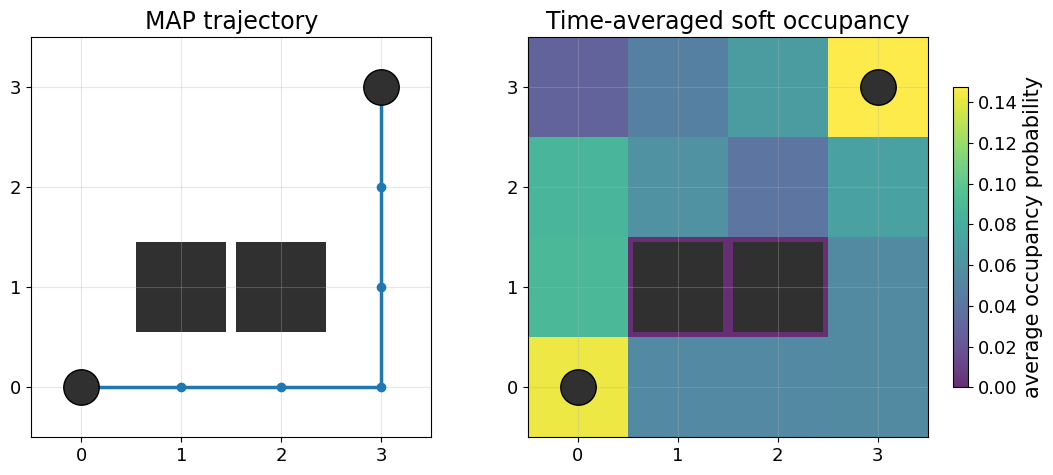

In [3]:
fig,axes=plt.subplots(1,2,figsize=(11.5,5))
for ax,title in zip(axes,['MAP trajectory','Time-averaged soft occupancy']):
    ax.set_xlim(-.5,W-.5); ax.set_ylim(-.5,H-.5); ax.set_aspect('equal'); ax.set_xticks(range(W)); ax.set_yticks(range(H)); ax.grid(alpha=.3)
    for o in obstacles: ax.add_patch(plt.Rectangle((o[0]-.45,o[1]-.45),.9,.9,facecolor='#303030'))
    ax.scatter([start[0],goal[0]],[start[1],goal[1]],s=650,facecolor='#303030',edgecolor='black',zorder=4)
    ax.text(*start,'S',ha='center',va='center',color='white',fontsize=14,fontweight='bold'); ax.text(*goal,'G',ha='center',va='center',color='white',fontsize=14,fontweight='bold')
    ax.set_title(title)
mp=np.array(map_path); axes[0].plot(mp[:,0],mp[:,1],marker='o',linewidth=2.5,zorder=3)
avg=occ.mean(axis=0); im=axes[1].imshow(avg,origin='lower',extent=[-.5,W-.5,-.5,H-.5],alpha=.82)
fig.colorbar(im,ax=axes[1],shrink=.75,label='average occupancy probability')
fig.tight_layout(); save_figure(fig,'ch11_04_robot_path_inference'); plt.show()

## Exercises

1. Compare the MAP path with the most probable state at each intermediate time. Why need these not form the same path?
2. Increase $\beta$ and track the path entropy. Relate the zero-temperature limit to deterministic shortest-path planning.
3. Add a stochastic ``wind'' transition and condition on successful arrival. Interpret the resulting posterior as a bridge process.
4. Replace the fixed costs by learnable parameters and formulate an inverse-control problem from demonstrated trajectories.